# Imports

In [10]:
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
import matplotlib.pyplot as plt

import sys
sys.path.append('..')  # to access pipeline.py
from pipeline import (
    AUTOENCODER_FEATURES,
    AUTOENCODER_SCALE_COLS,
    filter_port,
)

# Load and split by protocol

In [11]:
df = pd.read_csv('../ryu-controller/traffic_log.csv')

# keep only normal traffic
df = df[df['Traffic'] == 'Normal']

# split by L4 protocol
df_icmp = df[df['Ip_protocole'] == 'icmp'].copy()
df_tcp  = df[df['Ip_protocole'] == 'tcp'].copy()
df_udp  = df[df['Ip_protocole'] == 'udp'].copy()

print(f'ICMP: {len(df_icmp)} | TCP: {len(df_tcp)} | UDP: {len(df_udp)}')

ICMP: 83 | TCP: 3139 | UDP: 700


# Preprocessing function

In [12]:
def preprocess_protocol(df, protocol):
    """Select features, filter ports, scale, return array + fitted scaler."""
    feature_cols = AUTOENCODER_FEATURES[protocol]
    scale_cols   = AUTOENCODER_SCALE_COLS[protocol]

    X = df[feature_cols].copy()

    # port filtering
    if 'Port_dst' in X.columns:
        X['Port_dst'] = X['Port_dst'].apply(filter_port)

    # drop missing
    X = X.dropna()

    # fit scaler on scale columns only
    scaler = StandardScaler()
    X[scale_cols] = scaler.fit_transform(X[scale_cols])

    return X.values.astype(np.float32), scaler

# Autoencoder builder

In [13]:
def build_autoencoder(input_dim):
    """Simple dense autoencoder, bottleneck at 1/4 input size."""
    inp       = Input(shape=(input_dim,))
    encoded   = Dense(input_dim * 2, activation='relu')(inp)
    bottleneck= Dense(input_dim // 4, activation='relu')(encoded)
    decoded   = Dense(input_dim * 2, activation='relu')(bottleneck)
    out       = Dense(input_dim, activation='linear')(decoded)

    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=0.001), loss=MeanSquaredError())
    return model

# Train one protocol

In [14]:
def train_and_save(df, protocol):
    print(f'\n--- {protocol.upper()} ---')

    if len(df) < 30:
        print(f'Not enough samples ({len(df)}), skipping.')
        return None

    X, scaler = preprocess_protocol(df, protocol)
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

    model = build_autoencoder(X_train.shape[1])
    model.fit(
        X_train, X_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, X_test),
        verbose=1,
    )

    # compute RMSE on test set to pick threshold
    X_pred = model.predict(X_test)
    mse    = np.mean(np.power(X_test - X_pred, 2), axis=1)
    rmse   = np.sqrt(mse)

    threshold = np.percentile(rmse, 95)
    print(f'Suggested threshold (95th percentile): {threshold:.4f}')

    # plot
    plt.figure()
    plt.hist(rmse, bins=50)
    plt.axvline(threshold, color='red', label=f'threshold={threshold:.4f}')
    plt.title(f'{protocol.upper()} reconstruction error distribution')
    plt.xlabel('RMSE')
    plt.legend()
    plt.show()

    # save
    model.save(f'../ryu-controller/{protocol}.h5')
    with open(f'../ryu-controller/std_{protocol}.pkl', 'wb') as f:
        pickle.dump(scaler, f)

    print(f'Saved {protocol}.h5 and std_{protocol}.pkl')
    return threshold

In [15]:
print(df.columns.tolist())

['Timestamp', 'Ip_src', 'Ip_dst', 'Same_ip', 'Port_src', 'Port_dst', 'Ip_protocole', 'Type_protocole', 'Icmp', 'Icmp_code', 'Icmp_type', 'Tcp', 'Udp', 'ACK', 'PSH', 'RST', 'SYN', 'FIN', 'Http', 'Ftp', 'Smtp', 'Dns', 'Flow_duration', 'Flow_dur_nsec', 'Packet_count', 'Bytes', 'Pkt_per_sec', 'Pkt_per_nsec', 'Bytes_per_sec', 'Bytes_per_nsec', 'Traffic', 'Attack_type']



--- ICMP ---
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.2820 - val_loss: 0.2519
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2747 - val_loss: 0.2468
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2695 - val_loss: 0.2430
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2654 - val_loss: 0.2400
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2615 - val_loss: 0.2369
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2573 - val_loss: 0.2336
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2526 - val_loss: 0.2301
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2475 - val_loss: 0.2259
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2420 - val_loss: 0.2213
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2362 - val_loss: 0.2162
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2298 - val_loss: 0.2109
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.2223 - val_

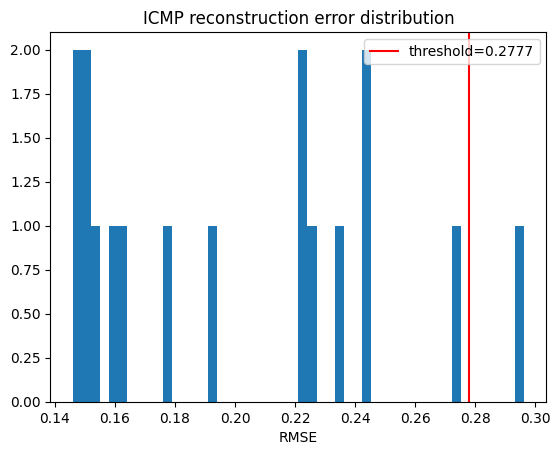

Saved icmp.h5 and std_icmp.pkl

--- TCP ---
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3221 - val_loss: 0.1692
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1246 - val_loss: 0.0902
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0757 - val_loss: 0.0674
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0638 - val_loss: 0.0620
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0585 - val_loss: 0.0574
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0535 - val_loss: 0.0525
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0483 - val_loss: 0.0472
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0436 - val_loss: 0.0427
Epoch 9/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0396 - val_loss: 0.0392
Epoch 10/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0366 - val_loss: 0.0363
Epoch 11/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0341 - val_loss: 0.0341
Epoch 12/50
79/79 ━━━━━━━━━━━━

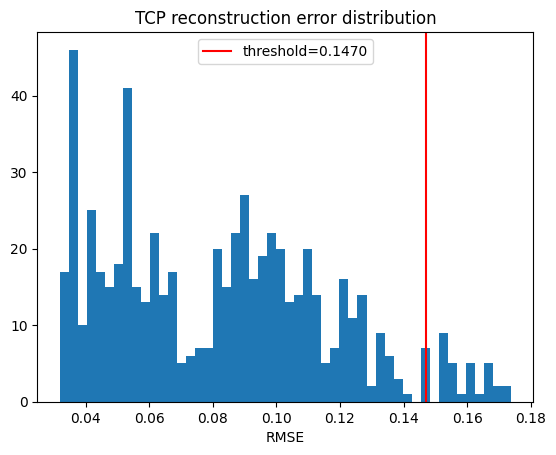

Saved tcp.h5 and std_tcp.pkl

--- UDP ---
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 82.2305 - val_loss: 81.3354
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 76.5366 - val_loss: 72.3076
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 62.3425 - val_loss: 51.3349
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.0542 - val_loss: 22.9063
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.0654 - val_loss: 2.9840
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9554 - val_loss: 0.3698
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2741 - val_loss: 0.2032
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1836 - val_loss: 0.1745
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1686 - val_loss: 0.1678
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1636 - val_loss: 0.1640
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1599 - val_loss: 0.1634
Epoch 12/50
18/18 ━━━━━

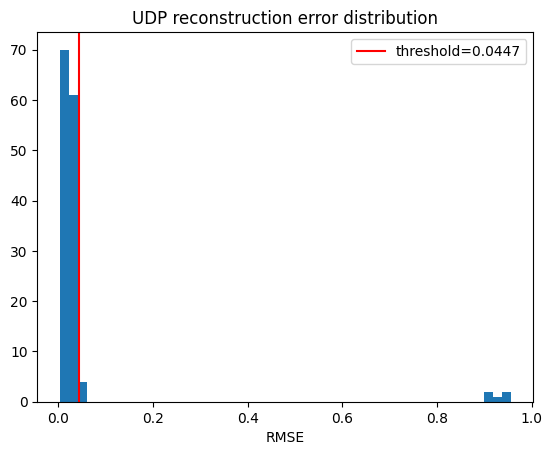

Saved udp.h5 and std_udp.pkl


In [16]:
threshold_icmp = train_and_save(df_icmp, 'icmp')
threshold_tcp  = train_and_save(df_tcp,  'tcp')
threshold_udp  = train_and_save(df_udp,  'udp')

# Print final thresholds to update in monitor.py

In [17]:
print(f'\nUpdate these in monitor.py:')
print(f'THRESHOLD_ICMP = {threshold_icmp:.4f}')
print(f'THRESHOLD_TCP  = {threshold_tcp:.4f}')
print(f'THRESHOLD_UDP  = {threshold_udp:.4f}')


Update these in monitor.py:
THRESHOLD_ICMP = 0.2777
THRESHOLD_TCP  = 0.1470
THRESHOLD_UDP  = 0.0447
